In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

Matplotlib is building the font cache; this may take a moment.


In [2]:
import os

os.chdir(r"C:\Users\hp\OneDrive\Documents\MutualFundAnalytics")

print(os.getcwd())

C:\Users\hp\OneDrive\Documents\MutualFundAnalytics


In [5]:
base_path = os.path.join("data", "raw")

fund_master = pd.read_csv(base_path + r"\01_fund_master.csv")
nav = pd.read_csv(base_path + r"\02_nav_history.csv")
aum = pd.read_csv(base_path + r"\03_aum_by_fund_house.csv")
sip = pd.read_csv(base_path + r"\04_monthly_sip_inflows.csv")
category = pd.read_csv(base_path + r"\05_category_inflows.csv")
folio = pd.read_csv(base_path + r"\06_industry_folio_count.csv")
performance = pd.read_csv(base_path + r"\07_scheme_performance.csv")
transactions = pd.read_csv(base_path + r"\08_investor_transactions.csv")
holdings = pd.read_csv(base_path + r"\09_portfolio_holdings.csv")
benchmark = pd.read_csv(base_path + r"\10_benchmark_indices.csv")

In [7]:
print("Fund Master:", fund_master.shape)
print("NAV:", nav.shape)
print("AUM:", aum.shape)
print("SIP:", sip.shape)
print("Category:", category.shape)
print("Folio:", folio.shape)
print("Performance:", performance.shape)
print("Transactions:", transactions.shape)
print("Holdings:", holdings.shape)
print("Benchmark:", benchmark.shape)

Fund Master: (40, 15)
NAV: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Category: (144, 3)
Folio: (21, 6)
Performance: (40, 19)
Transactions: (32778, 13)
Holdings: (322, 8)
Benchmark: (8050, 3)


In [6]:
# Display dataset information

datasets = {
    "Fund Master": fund_master,
    "NAV": nav,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Performance": performance,
    "Transactions": transactions,
    "Holdings": holdings,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print("="*60)
    print(name)
    print(df.info())
    

Fund Master
<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     str    
 2   scheme_name         40 non-null     str    
 3   category            40 non-null     str    
 4   sub_category        40 non-null     str    
 5   plan                40 non-null     str    
 6   launch_date         40 non-null     str    
 7   benchmark           40 non-null     str    
 8   expense_ratio_pct   40 non-null     float64
 9   exit_load_pct       40 non-null     float64
 10  min_sip_amount      40 non-null     int64  
 11  min_lumpsum_amount  40 non-null     int64  
 12  fund_manager        40 non-null     str    
 13  risk_category       40 non-null     str    
 14  sebi_category_code  40 non-null     str    
dtypes: float64(2), int64(3), str(10)
memory usage: 4.8 KB
None

In [7]:
for name, df in datasets.items():
    print("="*60)
    print(name)
    print(df.isnull().sum())

Fund Master
amfi_code             0
fund_house            0
scheme_name           0
category              0
sub_category          0
plan                  0
launch_date           0
benchmark             0
expense_ratio_pct     0
exit_load_pct         0
min_sip_amount        0
min_lumpsum_amount    0
fund_manager          0
risk_category         0
sebi_category_code    0
dtype: int64
NAV
amfi_code    0
date         0
nav          0
dtype: int64
AUM
date              0
fund_house        0
aum_lakh_crore    0
aum_crore         0
num_schemes       0
dtype: int64
SIP
month                         0
sip_inflow_crore              0
active_sip_accounts_crore     0
new_sip_accounts_lakh         0
sip_aum_lakh_crore            0
yoy_growth_pct               12
dtype: int64
Category
month               0
category            0
net_inflow_crore    0
dtype: int64
Folio
month                  0
total_folios_crore     0
equity_folios_crore    0
debt_folios_crore      0
hybrid_folios_crore    0
others_f

In [8]:
for name, df in datasets.items():
    print("="*60)
    print(name)
    display(df.describe(include="all"))
    

Fund Master


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
count,40.000000,40,40,40,40,40,40,40,40.000000,40.000000,40.0,40.000000,40,40,40
unique,NaN,10,40,2,12,2,34,10,NaN,NaN,NaN,NaN,29,5,9
top,NaN,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2013-01-01,NIFTY 100 TRI,NaN,NaN,NaN,NaN,Sohini Andani,Moderate,EC01
freq,NaN,5,1,34,14,32,7,14,NaN,NaN,NaN,NaN,2,16,14
mean,120247.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.237000,0.812500,500.0,1277.500000,NaN,NaN,NaN
std,14534.998667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.386584,0.387091,0.0,1082.847031,NaN,NaN,NaN
min,100016.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.550000,0.000000,500.0,100.000000,NaN,NaN,NaN
25%,118632.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.787500,1.000000,500.0,1000.000000,NaN,NaN,NaN
50%,119551.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.425000,1.000000,500.0,1000.000000,NaN,NaN,NaN
75%,120842.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.540000,1.000000,500.0,1000.000000,NaN,NaN,NaN


NAV


,amfi_code,date,nav
count,46000.000000,46000,46000.000000
unique,NaN,1150,NaN
top,NaN,2022-01-03,NaN
freq,NaN,40,NaN
mean,120247.000000,NaN,269.570265
std,14352.317221,NaN,577.187060
min,100016.000000,NaN,26.136600
25%,118632.750000,NaN,69.170425
50%,119551.500000,NaN,122.732150
75%,120842.250000,NaN,260.338675


AUM


...

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
count,32778,32778,32778.000000,32778,32778.000000,32778,32778,32778,32778,32778,32778.000000,32778,32778
unique,5000,516,NaN,3,NaN,12,24,2,5,2,NaN,4,2
top,INV001497,2025-04-28,NaN,SIP,NaN,Punjab,Kolkata,T30,26-35,Male,NaN,Net Banking,Verified
freq,12,88,NaN,19716,NaN,2965,2748,21719,13463,21809,NaN,8250,30146
mean,NaN,NaN,120264.617518,NaN,107437.318628,NaN,NaN,NaN,NaN,NaN,26.181219,NaN,NaN
std,NaN,NaN,14370.205345,NaN,150415.905084,NaN,NaN,NaN,NaN,NaN,20.805425,NaN,NaN
min,NaN,NaN,100016.000000,NaN,400.000000,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,NaN
25%,NaN,NaN,118632.000000,NaN,3153.000000,NaN,NaN,NaN,NaN,NaN,10.600000,NaN,NaN
50%,NaN,NaN,119551.000000,NaN,17782.500000,NaN,NaN,NaN,NaN,NaN,19.700000,NaN,NaN
75%,NaN,NaN,120843.000000,NaN,189324.250000,NaN,NaN,NaN,NaN,NaN,37.400000,NaN,NaN


Holdings


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
count,322.000000,322,322,322,322.000000,322.000000,322.000000,322
unique,NaN,30,30,14,NaN,NaN,NaN,1
top,NaN,BHARTIARTL,Bharti Airtel Ltd,Banking,NaN,NaN,NaN,2025-12-31
freq,NaN,15,15,60,NaN,NaN,NaN,322
mean,121210.434783,NaN,NaN,NaN,10.558975,1008.846646,4080.870528,NaN
std,14669.377920,NaN,NaN,NaN,6.060137,543.827535,2265.186353,NaN
min,100016.000000,NaN,NaN,NaN,0.990000,55.740000,246.780000,NaN
25%,118633.000000,NaN,NaN,NaN,6.015000,513.702500,2081.985000,NaN
50%,119552.000000,NaN,NaN,NaN,9.395000,1045.670000,4138.995000,NaN
75%,120842.750000,NaN,NaN,NaN,13.917500,1477.502500,5914.307500,NaN


Benchmark


,date,index_name,close_value
count,8050,8050,8050.000000
unique,1150,7,NaN
top,2022-01-03,NIFTY50,NaN
freq,7,1150,NaN
mean,NaN,NaN,18351.950181
std,NaN,NaN,14169.995121
min,NaN,NaN,1444.130000
25%,NaN,NaN,2819.062500
50%,NaN,NaN,18392.960000
75%,NaN,NaN,26539.097500


In [9]:
# Convert date column to datetime
nav["date"] = pd.to_datetime(nav["date"])

# Average NAV across all funds for each day
daily_nav = (
    nav.groupby("date")["nav"]
       .mean()
       .reset_index()
)

daily_nav.head()

,date,nav
0,2022-01-03,207.213793
1,2022-01-04,206.890585
2,2022-01-05,207.226548
3,2022-01-06,207.190405
4,2022-01-07,207.081100


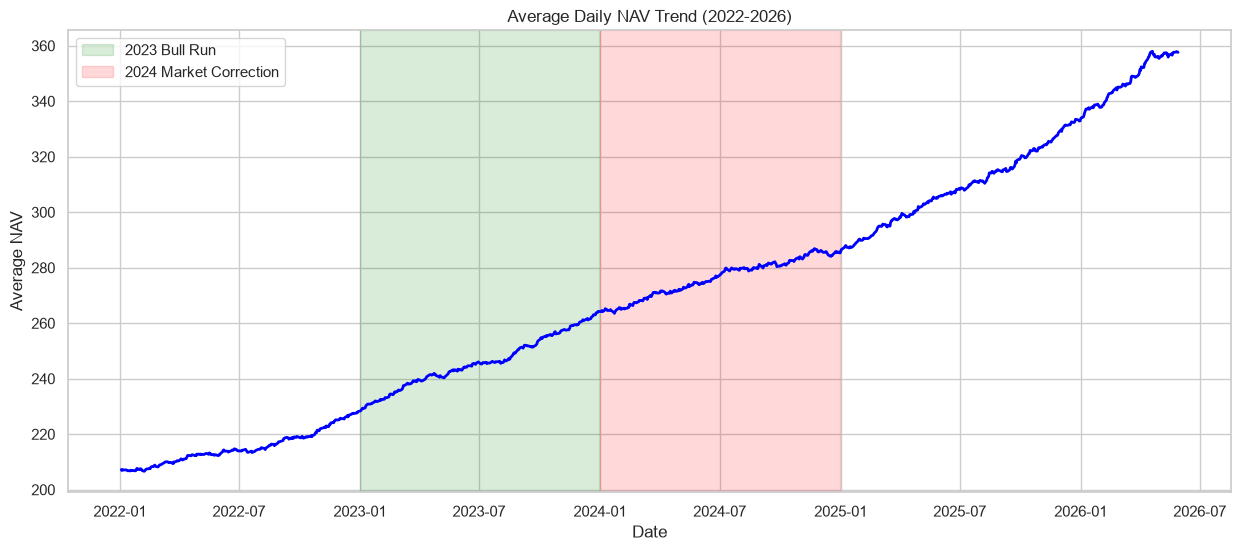

In [10]:
plt.figure(figsize=(15,6))

plt.plot(
    daily_nav["date"],
    daily_nav["nav"],
    color="blue",
    linewidth=2
)

plt.title("Average Daily NAV Trend (2022-2026)")
plt.xlabel("Date")
plt.ylabel("Average NAV")

# Highlight 2023 Bull Run
plt.axvspan(
    pd.to_datetime("2023-01-01"),
    pd.to_datetime("2023-12-31"),
    color="green",
    alpha=0.15,
    label="2023 Bull Run"
)

# Highlight 2024 Market Correction
plt.axvspan(
    pd.to_datetime("2024-01-01"),
    pd.to_datetime("2024-12-31"),
    color="red",
    alpha=0.15,
    label="2024 Market Correction"
)

plt.legend()
plt.grid(True)

plt.show()


In [11]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [12]:
aum.columns


Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')

In [13]:
# Convert date column to datetime
aum["date"] = pd.to_datetime(aum["date"])

# Create Year column
aum["Year"] = aum["date"].dt.year

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,Year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


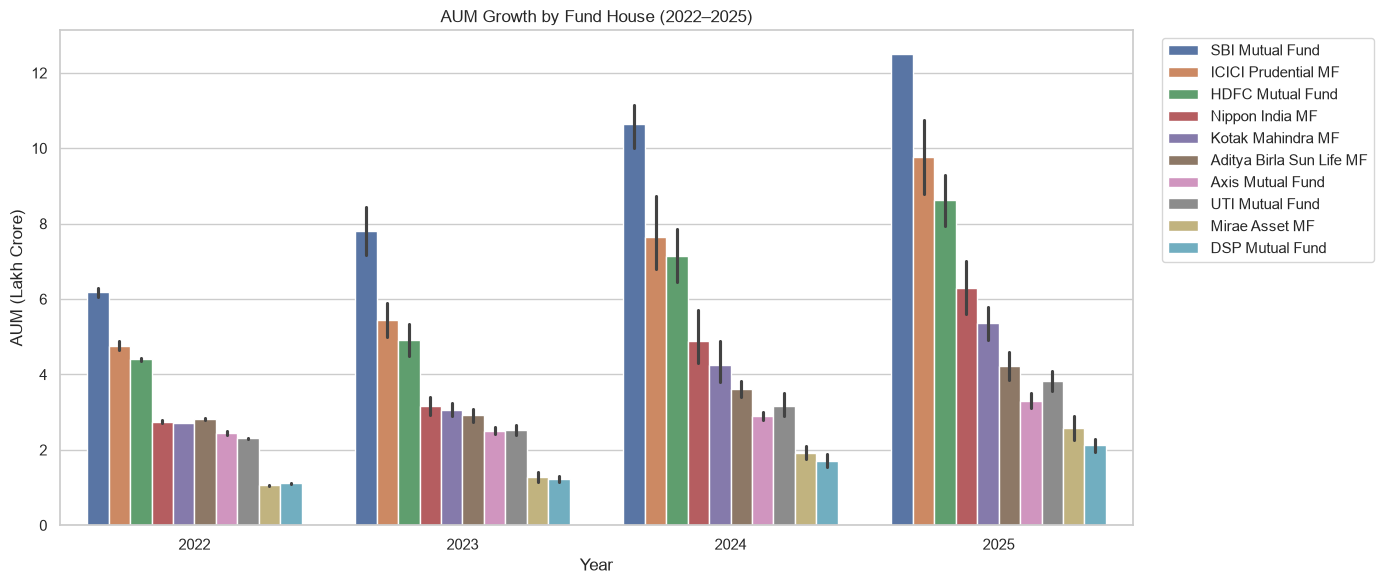

In [14]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="Year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()

plt.show()

In [15]:
sbi = aum[aum["fund_house"]=="SBI Mutual Fund"]

print(sbi[["Year","aum_lakh_crore"]])

    Year  aum_lakh_crore
0   2022            6.05
10  2022            6.30
20  2023            7.17
30  2023            8.45
40  2024           10.00
50  2024           10.80
60  2024           11.14
70  2025           12.50
80  2025           12.50


In [16]:
sip.head()


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [17]:
sip.columns

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')

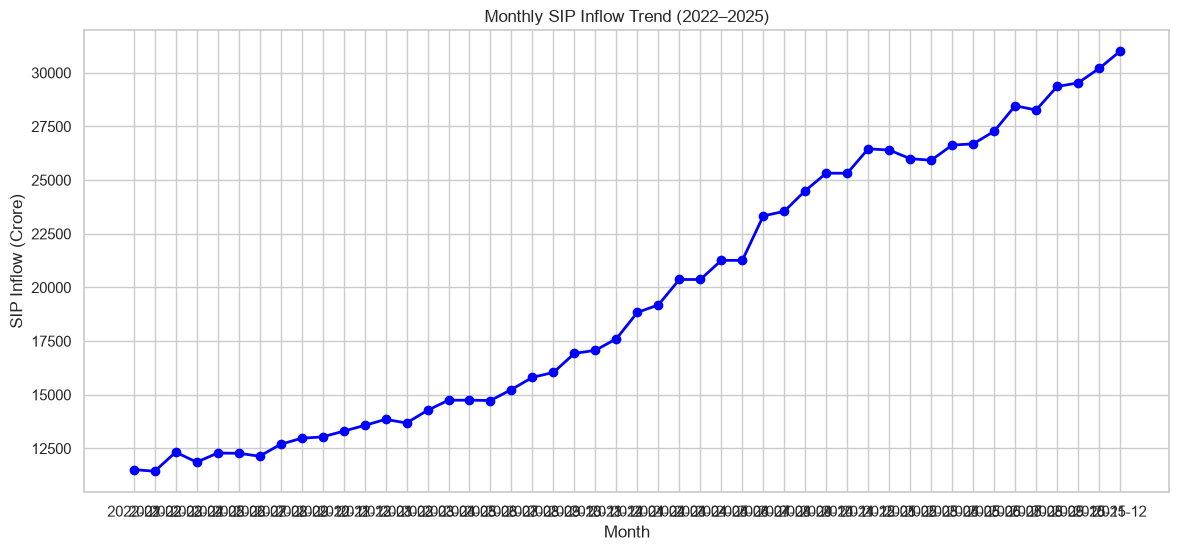

In [18]:
plt.figure(figsize=(14,6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o",
    linewidth=2,
    color="blue"
)

plt.title("Monthly SIP Inflow Trend (2022–2025)")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")
plt.grid(True)

plt.show()

In [19]:
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]
max_row

month                        2025-12
sip_inflow_crore               31002
active_sip_accounts_crore       9.35
new_sip_accounts_lakh            9.8
sip_aum_lakh_crore              15.9
yoy_growth_pct                 17.17
Name: 47, dtype: object

In [20]:
sip["month"] = pd.to_datetime(sip["month"])

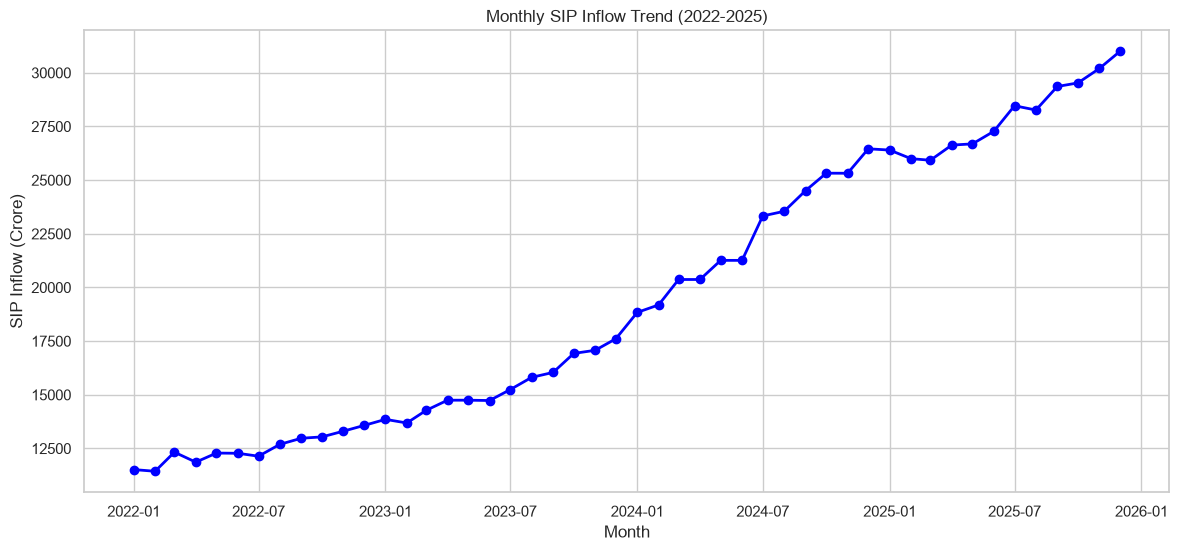

In [21]:
plt.figure(figsize=(14,6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o",
    linewidth=2,
    color="blue"
)

plt.title("Monthly SIP Inflow Trend (2022-2025)")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")
plt.grid(True)

plt.show()

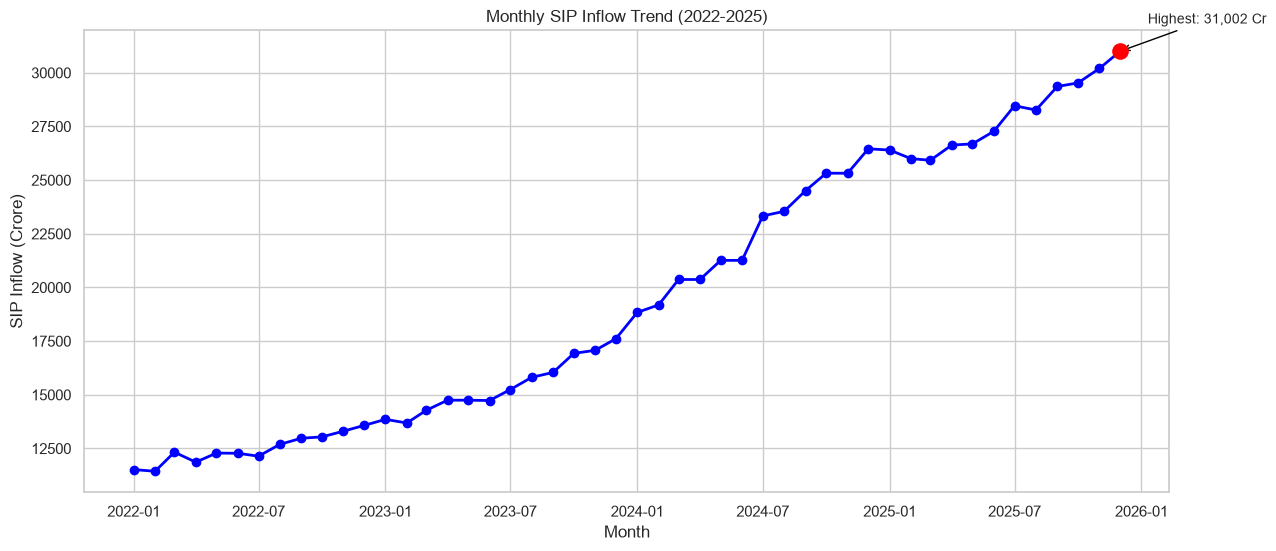

In [22]:
plt.figure(figsize=(14,6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o",
    linewidth=2,
    color="blue"
)

# Highest point
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

plt.scatter(
    max_row["month"],
    max_row["sip_inflow_crore"],
    color="red",
    s=120,
    zorder=5
)

plt.annotate(
    f'Highest: {max_row["sip_inflow_crore"]:,} Cr',
    xy=(max_row["month"], max_row["sip_inflow_crore"]),
    xytext=(20,20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=10
)

plt.title("Monthly SIP Inflow Trend (2022-2025)")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")
plt.grid(True)

plt.show()

In [23]:
category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [24]:
category.columns

Index(['month', 'category', 'net_inflow_crore'], dtype='str')

In [25]:
category["month"] = pd.to_datetime(category["month"])

In [26]:
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

heatmap_data.head()

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


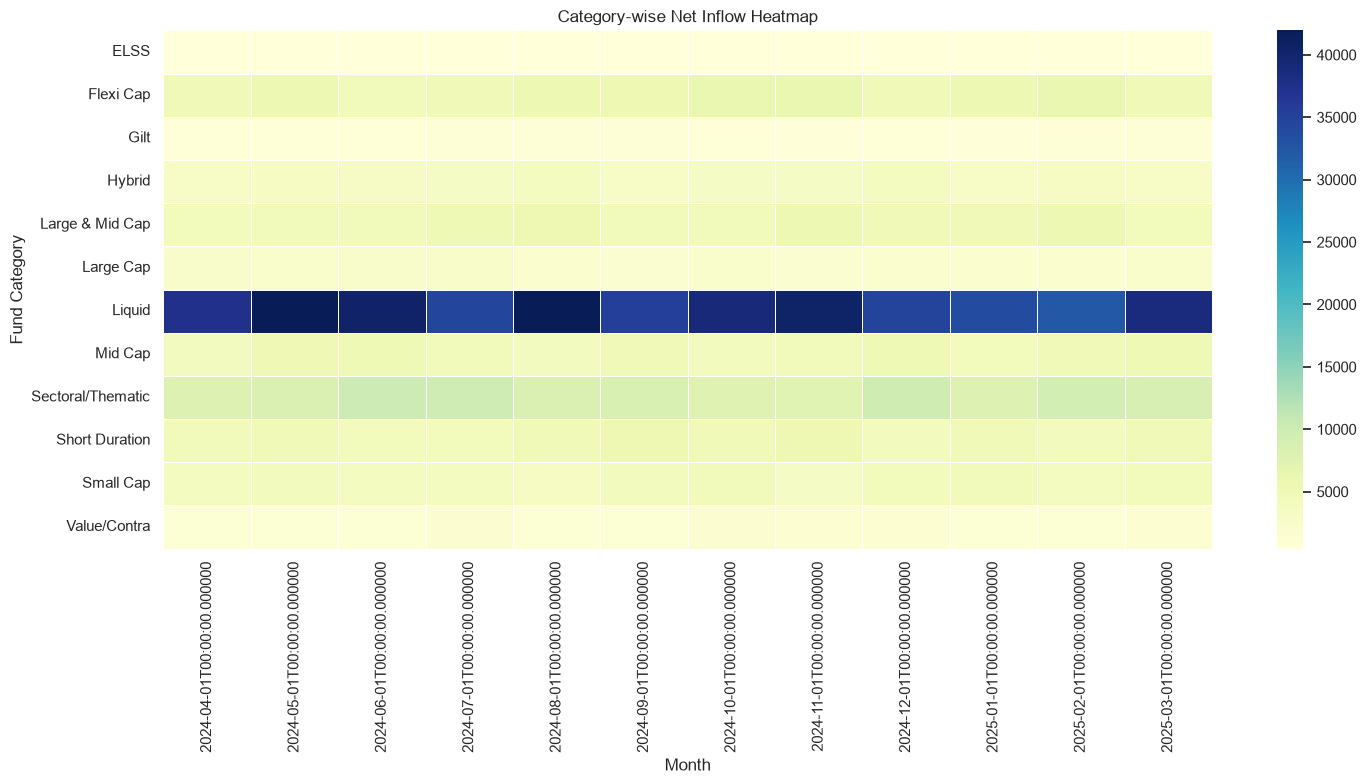

In [27]:
plt.figure(figsize=(15,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()
plt.show()

In [28]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [29]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [30]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  str    
 1   transaction_date    32778 non-null  str    
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  str    
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  str    
 6   city                32778 non-null  str    
 7   city_tier           32778 non-null  str    
 8   age_group           32778 non-null  str    
 9   gender              32778 non-null  str    
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  str    
 12  kyc_status          32778 non-null  str    
dtypes: float64(1), int64(2), str(10)
memory usage: 3.3 MB


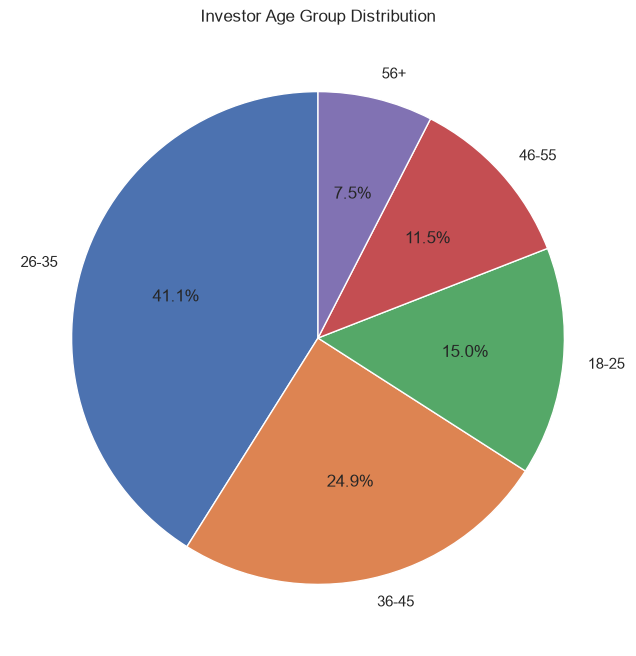

In [31]:
age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.show()

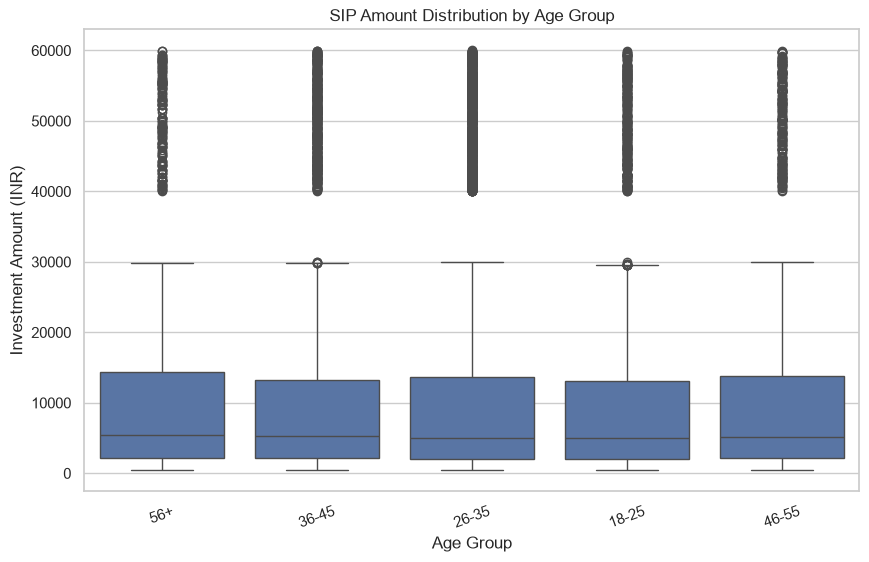

In [32]:
sip_txn = transactions[
    transactions["transaction_type"]=="SIP"
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_txn,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (INR)")
plt.xticks(rotation=20)

plt.show()

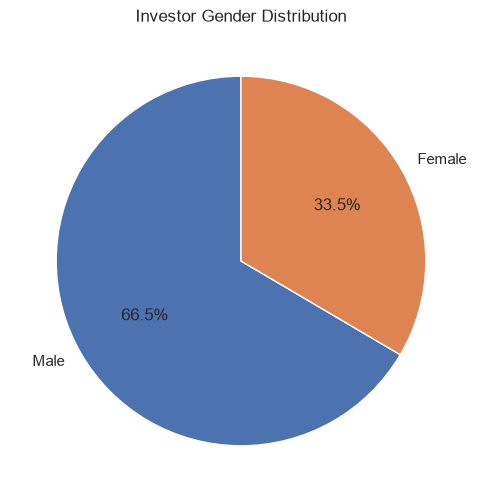

In [33]:
gender_counts = transactions["gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Gender Distribution")

plt.show()

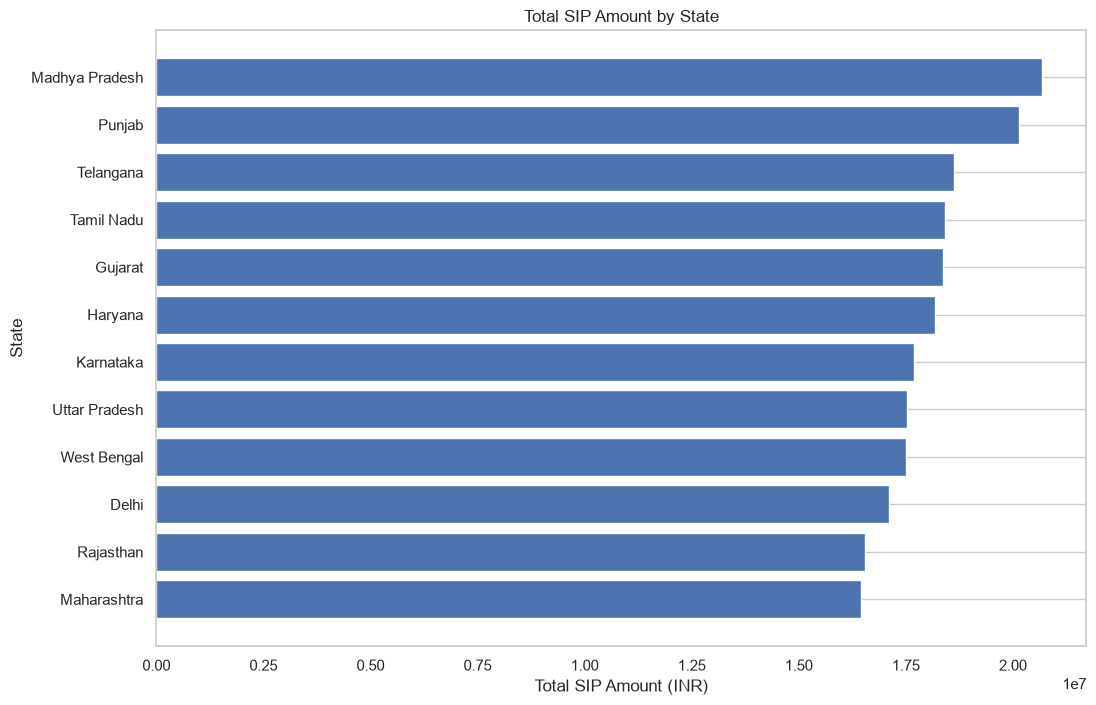

In [34]:
state_sip = (
    sip_txn.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

plt.barh(
    state_sip.index,
    state_sip.values
)

plt.xlabel("Total SIP Amount (INR)")
plt.ylabel("State")
plt.title("Total SIP Amount by State")

plt.gca().invert_yaxis()

plt.grid(axis="x")

plt.show()

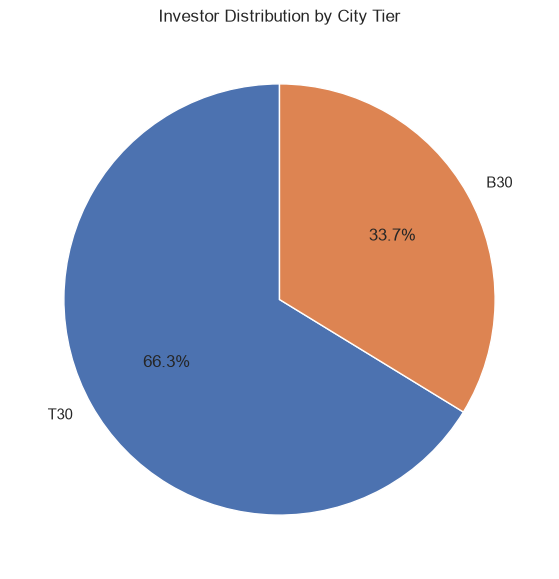

In [35]:
tier_counts = transactions["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Distribution by City Tier")

plt.show()

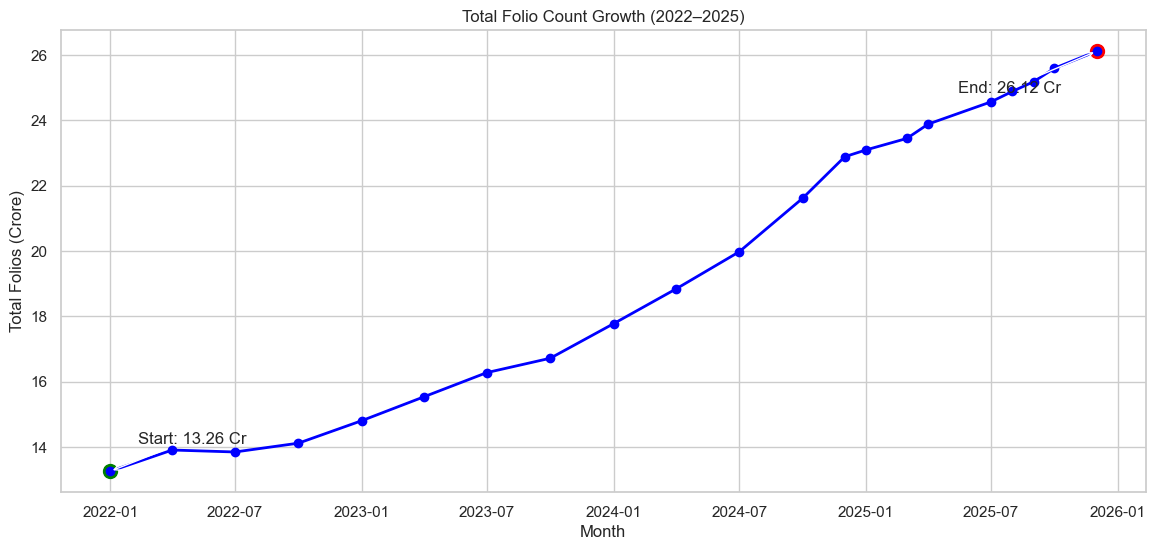

In [42]:
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(14,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=2,
    color="blue"
)

plt.scatter(
    folio.iloc[0]["month"],
    folio.iloc[0]["total_folios_crore"],
    color="green",
    s=100
)

plt.scatter(
    folio.iloc[-1]["month"],
    folio.iloc[-1]["total_folios_crore"],
    color="red",
    s=100
)

plt.annotate(
    f'Start: {folio.iloc[0]["total_folios_crore"]:.2f} Cr',
    (folio.iloc[0]["month"], folio.iloc[0]["total_folios_crore"]),
    xytext=(20,20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.annotate(
    f'End: {folio.iloc[-1]["total_folios_crore"]:.2f} Cr',
    (folio.iloc[-1]["month"], folio.iloc[-1]["total_folios_crore"]),
    xytext=(-100,-30),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.title("Total Folio Count Growth (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.grid(True)

plt.show()

In [36]:
folio.columns

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')

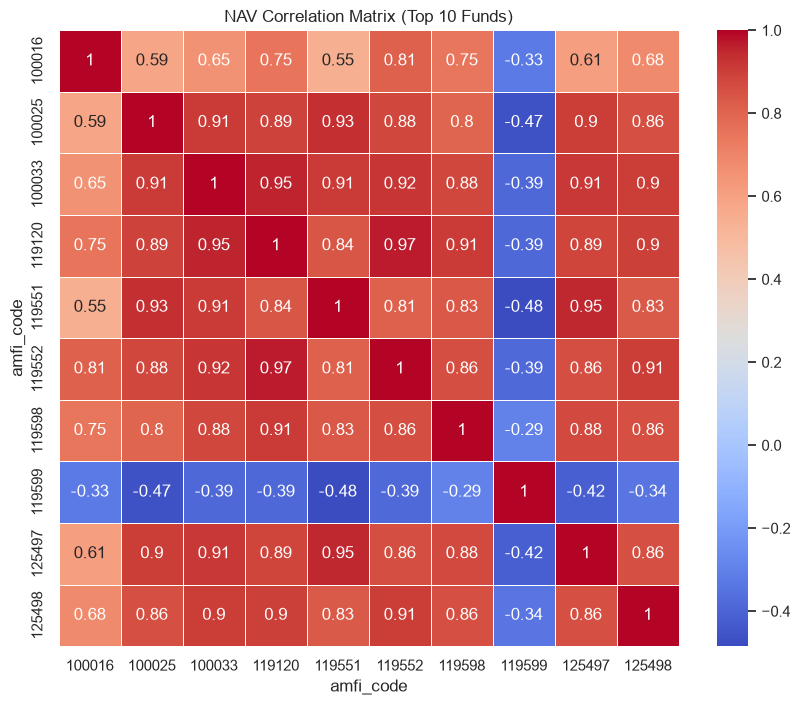

In [37]:
# Select 10 AMFI codes
top_funds = nav["amfi_code"].unique()[:10]

# Filter only those funds
corr_data = nav[nav["amfi_code"].isin(top_funds)]

# Pivot data
corr_matrix = corr_data.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

# Correlation
corr = corr_matrix.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("NAV Correlation Matrix (Top 10 Funds)")
plt.show()

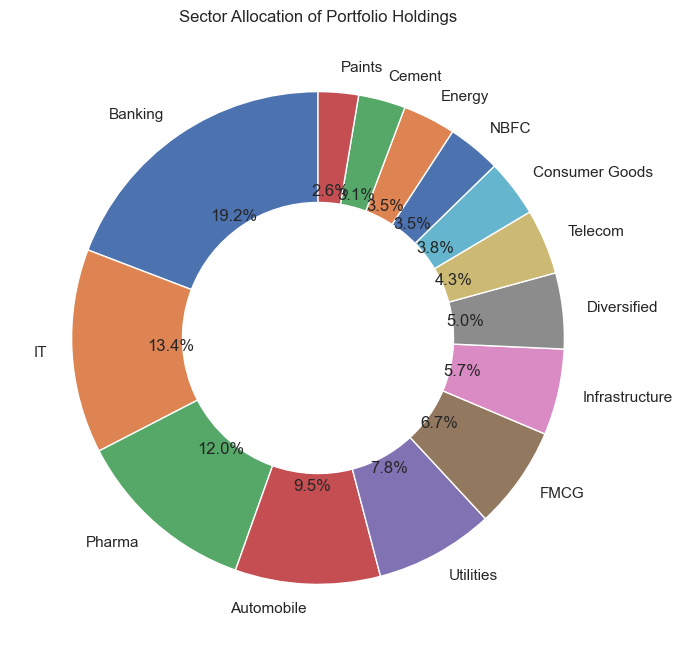

In [46]:
sector_data = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.45)
)

plt.title("Sector Allocation of Portfolio Holdings")

plt.show()

In [48]:
holdings.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')

In [49]:
holdings.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')

In [38]:
from IPython.display import Markdown, display

display(Markdown("""
# Key EDA Findings

1. NAV values showed a consistent upward trend from 2022 to 2026.
2. SBI Mutual Fund maintained the highest AUM (approximately Rs. 12.5 lakh crore).
3. Monthly SIP inflows reached an all-time high of approximately Rs. 31,002 crore.
4. Liquid funds recorded the highest category-wise inflows.
5. Total folio count increased from 13.26 crore to 26.12 crore.
6. Male investors represented about 66.5% of investors.
7. Tier-3 cities contributed around 66% of investors.
8. Banking, IT and Pharma were the largest portfolio sectors.
9. Top mutual funds showed strong positive NAV correlations.
10. Overall mutual fund industry showed consistent growth.
"""))


# Key EDA Findings

1. NAV values showed a consistent upward trend from 2022 to 2026.
2. SBI Mutual Fund maintained the highest AUM (approximately Rs. 12.5 lakh crore).
3. Monthly SIP inflows reached an all-time high of approximately Rs. 31,002 crore.
4. Liquid funds recorded the highest category-wise inflows.
5. Total folio count increased from 13.26 crore to 26.12 crore.
6. Male investors represented about 66.5% of investors.
7. Tier-3 cities contributed around 66% of investors.
8. Banking, IT and Pharma were the largest portfolio sectors.
9. Top mutual funds showed strong positive NAV correlations.
10. Overall mutual fund industry showed consistent growth.


In [51]:
plt.savefig("chart_name.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [52]:
plt.savefig("chart_name.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

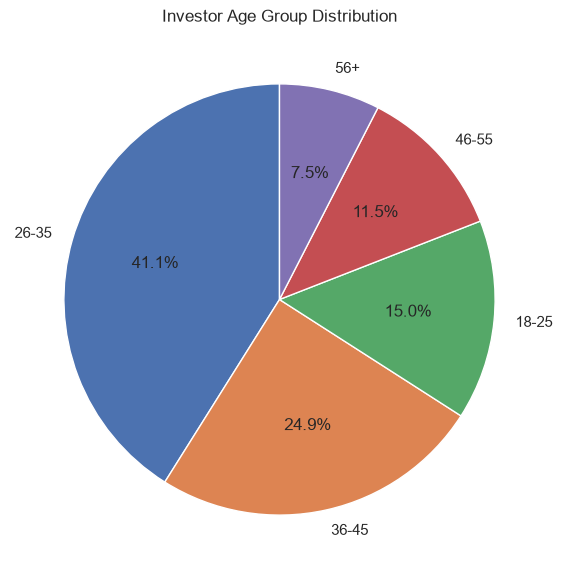

In [39]:
 

age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.savefig("10_Age_Group_Distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

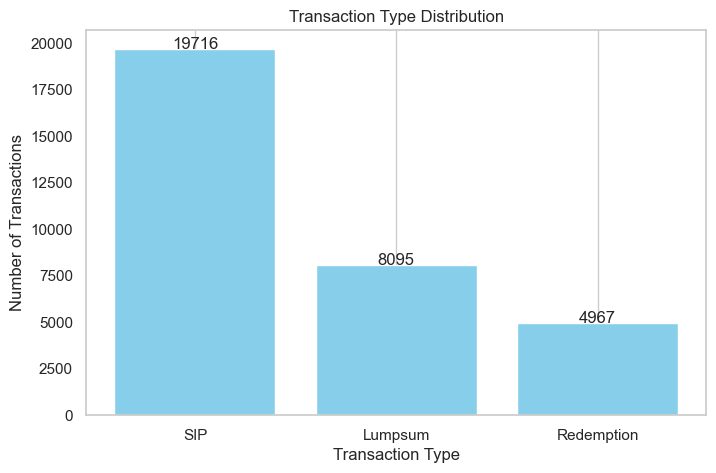

In [54]:


transaction_counts = transactions["transaction_type"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    transaction_counts.index,
    transaction_counts.values,
    color="skyblue"
)

plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

for i, v in enumerate(transaction_counts.values):
    plt.text(i, v, str(v), ha="center")

plt.grid(axis="y")

plt.savefig(
    "11_Transaction_Type_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

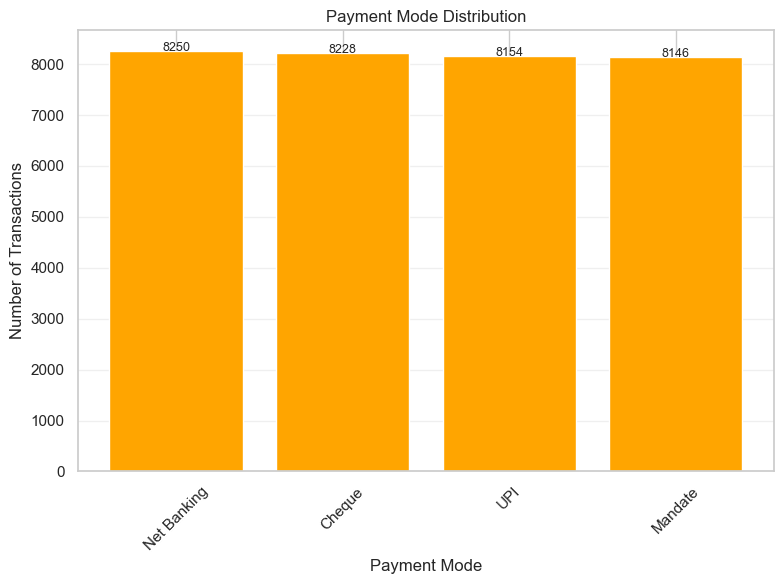

In [55]:
 

payment_counts = transactions["payment_mode"].value_counts()

plt.figure(figsize=(8,6))

plt.bar(
    payment_counts.index,
    payment_counts.values,
    color="orange"
)

plt.title("Payment Mode Distribution")
plt.xlabel("Payment Mode")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

for i, v in enumerate(payment_counts.values):
    plt.text(i, v, str(v), ha="center", fontsize=9)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "12_Payment_Mode_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [56]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

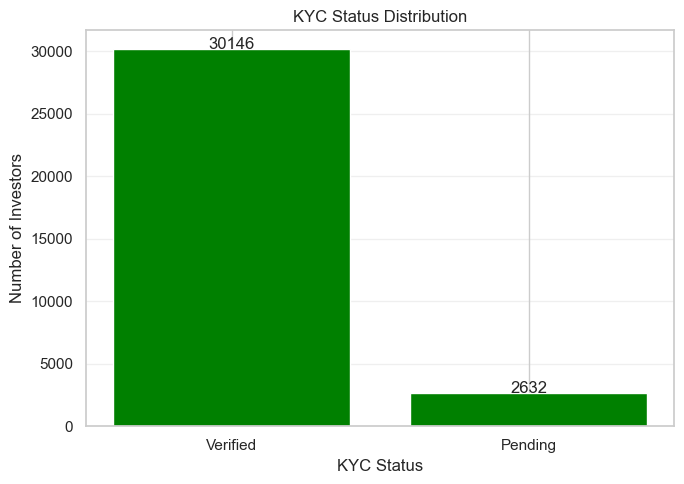

In [57]:
 
kyc_counts = transactions["kyc_status"].value_counts()

plt.figure(figsize=(7,5))

plt.bar(
    kyc_counts.index,
    kyc_counts.values,
    color="green"
)

plt.title("KYC Status Distribution")
plt.xlabel("KYC Status")
plt.ylabel("Number of Investors")

for i, v in enumerate(kyc_counts.values):
    plt.text(i, v, str(v), ha="center")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "13_KYC_Status_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [58]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='object')

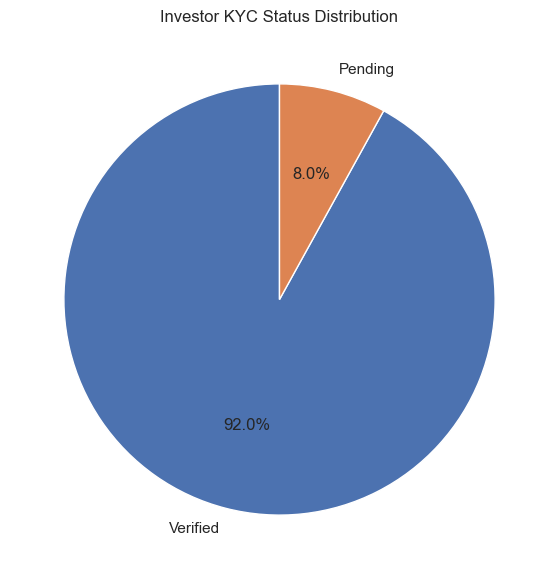

In [62]:
 # Chart 13: KYC Status Distribution

kyc_counts = transactions["kyc_status"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    kyc_counts,
    labels=kyc_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor KYC Status Distribution")

plt.savefig(
    "13_KYC_Status_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [65]:
 benchmark.columns
 

Index(['date', 'index_name', 'close_value'], dtype='object')

In [66]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


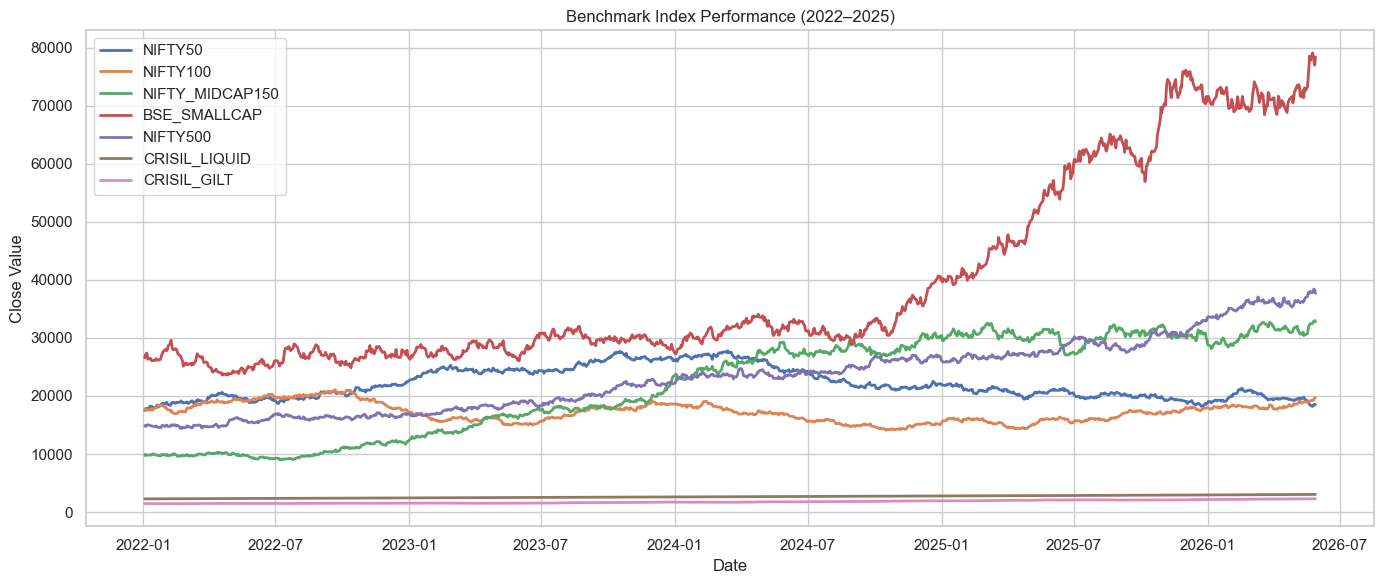

In [68]:
 

benchmark["date"] = pd.to_datetime(benchmark["date"])

plt.figure(figsize=(14,6))

for name in benchmark["index_name"].unique():

    data = benchmark[benchmark["index_name"] == name]

    plt.plot(
        data["date"],
        data["close_value"],   # <-- Correct column
        linewidth=2,
        label=name
    )

plt.title("Benchmark Index Performance (2022–2025)")
plt.xlabel("Date")
plt.ylabel("Close Value")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "14_Benchmark_Index_Trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

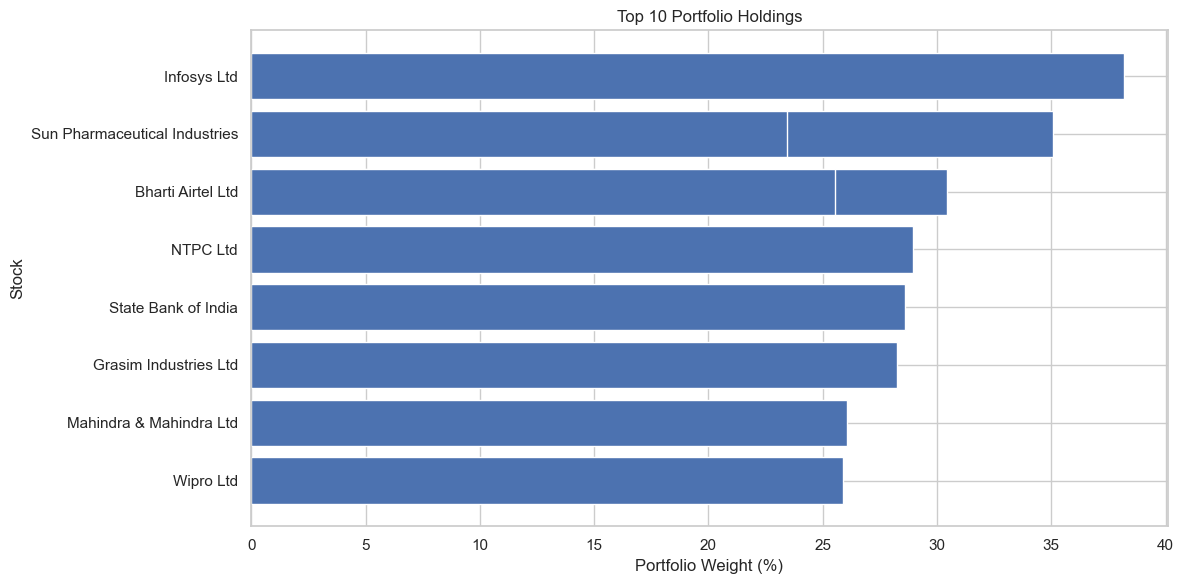

In [64]:
 
top10 = holdings.sort_values(
    by="weight_pct",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10["stock_name"],
    top10["weight_pct"]
)

plt.xlabel("Portfolio Weight (%)")
plt.ylabel("Stock")

plt.title("Top 10 Portfolio Holdings")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "15_Top10_Portfolio_Holdings.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()